# 

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from torchsummary import summary


from scipy.ndimage import zoom
from scipy.interpolate import RegularGridInterpolator

from M2.DP import DPForwardSolver
from M2.Utils.source import source
from M2.PINN.model import PINN, g, PINNForwardSolver
from M2.inverse_problem import inverse_function, inverse_function_differentiable
from M2.placement import optimize_sensors, local_search
from M2.Utils.visualization import check_seismograms

device = "cpu" #"mps"

In [2]:
from M2.PINN.training import train_pinn, train_pinn2
from M2.PINN.loss import loss_fn
from M2.Utils.conditions import c


ImportError: cannot import name 'c' from 'M2.Utils.conditions' (/Users/romain/Dropbox/Romain/ULB/M2-INFOS/MEMO-F524/MEMO-F424/src/M2/Utils/conditions.py)

## Utils :

In [3]:
def plot_trajectories(histories, true_epicenter, sensors, labels=None, colors=None, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5)):
    """
    histories: list of (N, 2) arrays
    true_epicenter: (ex, ey)
    sensors: (K, 2) tensor
    labels: list of strings, one per history
    colors: list of colors, one per history
    """
    if not isinstance(histories, list):
        histories = [histories]
    if labels is None:
        labels = [f"Trajectory {i}" for i in range(len(histories))]
    if colors is None:
        default = ["blue", "purple", "orange", "teal", "brown", "pink"]
        colors = default[:len(histories)]

    fig, ax = plt.subplots(figsize=(7, 7))

    for hist, label, color in zip(histories, labels, colors):
        hist = np.array(hist)
        ax.plot(hist[:, 0], hist[:, 1], color=color, linewidth=1.5, alpha=0.7, zorder=3, label=label)
        ax.scatter(hist[:-1, 0], hist[:-1, 1], color=color, s=40, edgecolors="white", linewidths=0.5, zorder=5)
        ax.scatter(hist[-1, 0], hist[-1, 1], color=color, s=60, edgecolors="white", linewidths=0.5, zorder=7)

    ax.scatter(hist[0, 0], hist[0, 1], marker=".", color="red", s=100, zorder=8, label="Initial guess")
    ax.scatter(*true_epicenter, marker="*", color="green", s=300, zorder=6, label="True epicenter")
    ax.scatter(sensors[:, 0], sensors[:, 1], marker="^", color="black", s=120, zorder=5, label="Seismometers")

    ax.set_xlabel("x (m)", fontsize=12)
    ax.set_ylabel("y (m)", fontsize=12)
    ax.set_title("Epicenter inversion trajectory", fontsize=14)
    ax.legend(fontsize=10, loc="upper left")
    ax.set_aspect("equal")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Experiments :

### Setup :

In [42]:
sensors_2 = torch.tensor([[-1.0, 0.0], [ 1.0, 0.0]], device="cpu")
sensors_3 = torch.tensor([[-1.0, 0.0], [ 1.0, 0.0], [ 0.0, 1.0]], device="cpu")
sensors_4 = torch.tensor([[-1.0, 0.0], [ 1.0, 0.0], [ 0.0,-1.0], [ 0.0, 1.0]], device="cpu")

sensors_asym = torch.tensor([[-1.0, 0.0], [1.0, 0.5]], device="cpu")

x_min, x_max, y_min, y_max = -50, 50, -50, 50
nx, ny = 500, 500
T, Nt = 5.0, 250  
A = 100.0
t0_src = 1.0
f0 = 1.0
gamma = 0.5 # -> sigma=1.0

init_guess = (1.0, 1.0)
true_ex, true_ey = 0, 0

torch.manual_seed(42)
N_EPI = 20
epicenters = torch.rand(N_EPI, 2) * 8 - 4   # uniform in [-4, 4]^2
print(f"{epicenters=}")

epicenters=tensor([[ 3.0582,  3.3200],
        [-0.9371,  3.6744],
        [-0.8764,  0.8072],
        [-1.9474,  2.3491],
        [ 3.5262, -2.9345],
        [ 3.4768,  0.7486],
        [ 2.9552,  0.5417],
        [ 1.9288, -0.5648],
        [ 3.0835,  0.5912],
        [-1.8674,  1.0196],
        [-1.8429, -0.4691],
        [-1.6246,  2.6535],
        [-3.1575, -1.8440],
        [-1.1295, -2.4051],
        [ 0.3775, -3.9507],
        [ 3.6124, -3.3979],
        [ 3.0881,  0.6657],
        [-1.2988,  2.4718],
        [ 0.6234,  3.2319],
        [ 0.4373, -1.2615]])


In [5]:
COLOR_CONST_SYM = "blue"  # blue
COLOR_CONST_ASYM = "#7AB3E0"  # light blue
COLOR_MAR_SYM = "orange"  # orange
COLOR_MAR_ASYM = "#F5C49A"  # light orange
COLOR_PINN_SYM = "green"   # green
COLOR_PINN_ASYM = "#A8D5A2"  # light green
COLOR_PINN_MAR_SYM = "red"    # red
COLOR_PINN_MAR_ASYM = "#F5A9A9"  # light red

colors = [COLOR_CONST_SYM, COLOR_CONST_ASYM, COLOR_MAR_SYM, COLOR_MAR_ASYM, COLOR_PINN_SYM, COLOR_PINN_ASYM]

Creation of the wavespeed field.

In [6]:
# Heterogeneous c from density
c_map = np.load("M2/Utils/Density_Test.npy")[8].reshape((51, 51))
c_map = zoom(c_map, 1024/51)

coords = np.linspace(-5, 5, 1024)
interp = RegularGridInterpolator((coords, coords), c_map, method='nearest', bounds_error=False, fill_value=None)

def c(x, y, t=0):
    if isinstance(x, torch.Tensor): x = x.cpu().detach().numpy()
    if isinstance(y, torch.Tensor): y = y.cpu().detach().numpy()
    return torch.tensor(interp(np.stack([y.ravel(), x.ravel()], axis=-1)).reshape(x.shape), dtype=torch.float32).to(device)

# Heterogeneous c from Marmousi
vp = np.load("M2/Utils/marmousi_vp.npy")
vp_normalized = vp / vp.max() * 7 # normalize to be physically consistent with c=10

x_coords = np.linspace(-5, 5, vp.shape[0]) 
y_coords = np.linspace(-5, 5, vp.shape[1])

interp_marmousi = RegularGridInterpolator((x_coords, y_coords), vp_normalized, method='nearest', bounds_error=False, fill_value=None)

def c_marmousi(x, y, t=0):
    if isinstance(x, torch.Tensor): 
        x = x.cpu().detach().numpy()
    if isinstance(y, torch.Tensor): 
        y = y.cpu().detach().numpy()
    return torch.tensor(interp_marmousi(np.stack([x.ravel(), y.ravel()], axis=-1)).reshape(x.shape),dtype=torch.float32)

# Constant c
def c_constant(x, y, t=0):
    if type(y) == np.ndarray:
        y = torch.tensor(y)
    if type(x) == np.ndarray:
        x = torch.tensor(x)
    return 5*torch.ones_like(y)

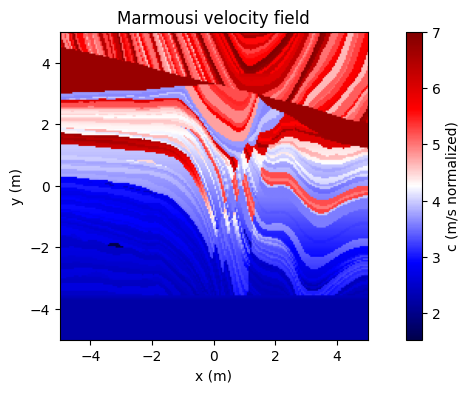

In [7]:
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = c_marmousi(X, Y)

plt.figure(figsize=(10, 4))
plt.imshow(Z.T, extent=[-5,5,-5,5], origin="lower", cmap="seismic", aspect="equal")
plt.colorbar(label="c (m/s normalized)")
plt.title("Marmousi velocity field")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.show()

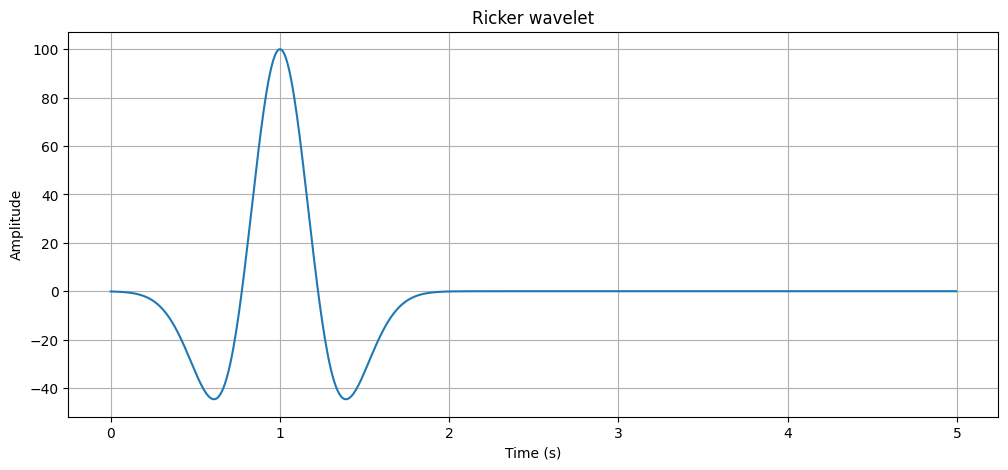

In [48]:
n_t = 1000
plt.figure(figsize=(12, 5))
plt.plot(torch.arange(0, 5, 5/n_t), source(torch.zeros(n_t), torch.zeros(n_t), torch.arange(0, 5, 5/n_t), 0, 0))
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Ricker wavelet")
plt.grid()
plt.show()

In [45]:
def make_dp(sensors, c_fn):
    return DPForwardSolver(
        sensors=sensors, c_fn=c_fn,
        x_min=x_min, x_max=x_max,
        y_min=y_min, y_max=y_max,
        Nx=nx, Ny=ny, Nt=Nt, T=T,
        A=A, t0=t0_src, f0=f0, gamma=gamma,
        device="cpu",
    )

def make_pinn(sensors, model):
    return PINNForwardSolver(
        model=model,
        sensors=sensors,
        t_max=T, n_t=Nt,
        x_min=x_min, x_max=x_max,
        y_min=y_min, y_max=y_max,
        device="cpu",
    )

In [10]:
dp_const = make_dp(sensors_2, c_constant)
dp_hetero = make_dp(sensors_2, c_marmousi)

dp_const_asym = make_dp(sensors_asym, c_constant)
dp_hetero_asym = make_dp(sensors_asym, c_marmousi)

In [11]:
# PINN model trained on constant c
model_pinn_const = torch.load("model_pinn_constant.pt", map_location=device, weights_only=False)
model_pinn_const.eval()

pinn_solver_const = make_pinn(sensors_2, model_pinn_const)
pinn_solver_const_asym = make_pinn(sensors_asym, model_pinn_const)

# PINN model trained on Marmousi
model_pinn_marmousi = torch.load("model_pinn_marmousi.pt", map_location=device, weights_only=False)

model_pinn_marmousi.eval()

pinn_solver_marmousi = make_pinn(sensors_2, model_pinn_marmousi)
pinn_solver_marmousi_asym = make_pinn(sensors_asym, model_pinn_marmousi)

In [12]:
traces_obs_constant = dp_const.forward(e_x=true_ex, e_y=true_ey).detach()
traces_obs_hetero = dp_hetero.forward(e_x=true_ex, e_y=true_ey).detach()
traces_pinn_const = pinn_solver_const.forward(0.0, 0.0).detach()
traces_pinn_hetero = pinn_solver_marmousi.forward(0.0, 0.0).detach()

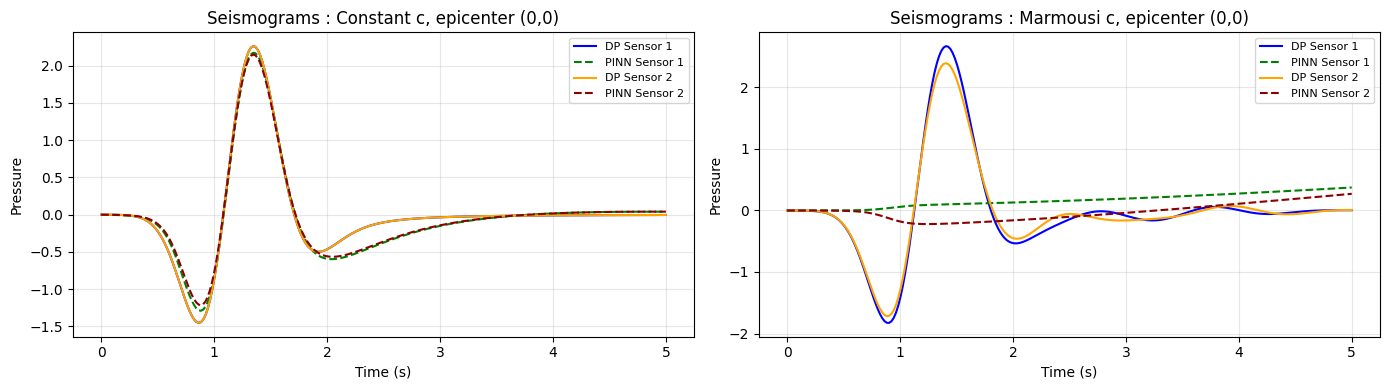

In [13]:
t_axis = np.linspace(0, T, Nt)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dp_colors   = ["blue", "orange"]   # blue, orange for DP
pinn_colors = ["green", "darkred"]   # green, dark red for PINN

for ax, dp_traces, pinn_traces, label in zip(
    axes,
    [traces_obs_constant, traces_obs_hetero],
    [traces_pinn_const, traces_pinn_hetero],
    ["Constant c", "Marmousi c"]
):
    for k in range(dp_traces.shape[1]):
        ax.plot(t_axis, dp_traces[:, k],
                color=dp_colors[k], linewidth=1.5,
                linestyle="-", label=f"DP Sensor {k+1}")
        ax.plot(t_axis, pinn_traces[:, k],
                color=pinn_colors[k], linewidth=1.5,
                linestyle="--", label=f"PINN Sensor {k+1}")
    ax.set_title(f"Seismograms : {label}, epicenter (0,0)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pressure")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("seismograms_comparison_dp_pinn.png", dpi=150, bbox_inches="tight")
plt.show()

### Simple test : 

100%|██████████| 10/10 [00:22<00:00,  2.23s/it]


True: (0, 0)
Recovered: (0.0035, 0.0000)
Error: 0.0035


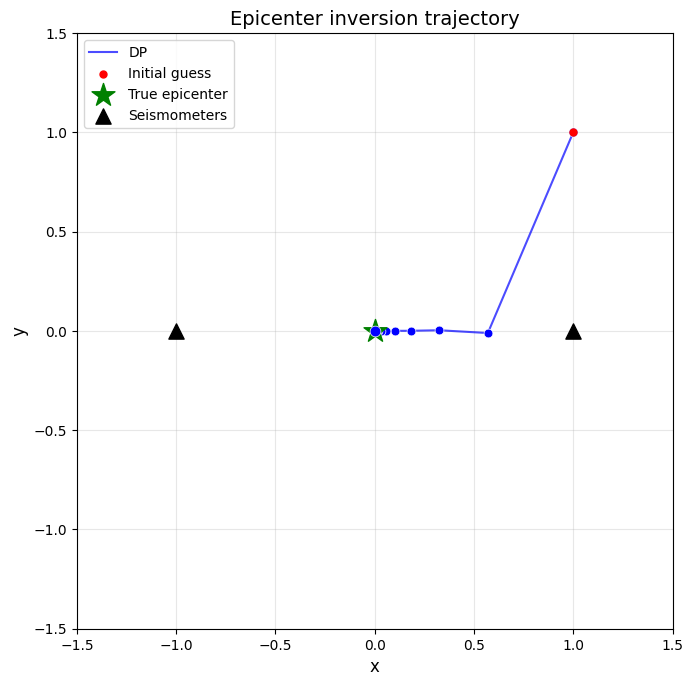

In [365]:
e_hat_dp_const, traces_pred_dp_const, _, history_dp_const = inverse_function(
    forward=dp_const,
    traces_obs=traces_obs_constant,
    dt=dp_const.dt,
    init=init_guess,
    steps=10,
    lr=1,
    max_iter=3,
    device="cpu",
)
history_dp_const.insert(0, init_guess)
history_dp = np.array(history_dp_const)

print(f"True: ({true_ex}, {true_ey})")
print(f"Recovered: ({e_hat_dp_const[0].item():.4f}, {e_hat_dp_const[1].item():.4f})")
print(f"Error: {torch.norm(e_hat_dp_const - torch.tensor([true_ex, true_ey])).item():.4f}")

plot_trajectories(history_dp, (true_ex, true_ey), sensors_2.cpu(), labels=["DP"])

100%|██████████| 10/10 [00:19<00:00,  1.96s/it]


True: (0, 0)
Recovered: (0.0000, -0.0000)
Error: 0.0000


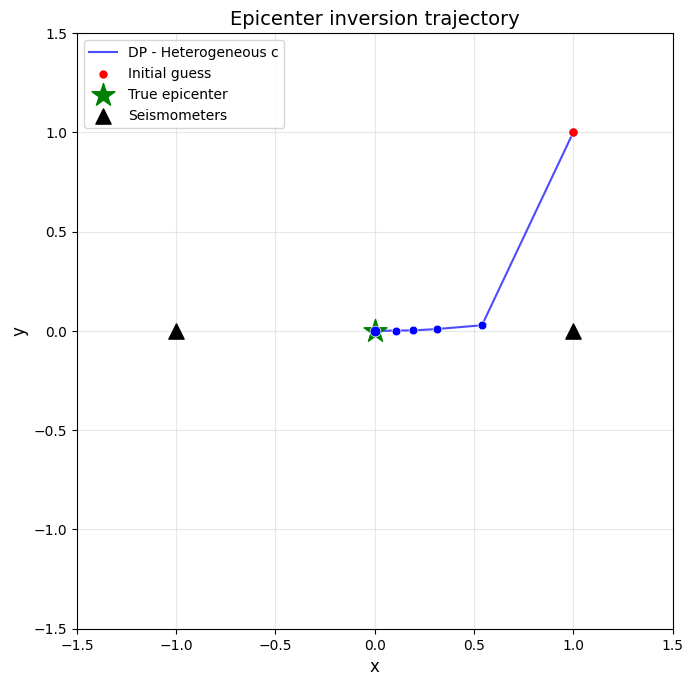

In [366]:
e_hat_dp_hetero, traces_pred_dp_hetero, _, history_dp_hetero = inverse_function(
    forward=dp_hetero,
    traces_obs=traces_obs_hetero,
    dt=dp_hetero.dt,
    init=init_guess,
    steps=10,
    lr=1,
    max_iter=3,
    device="cpu",
)
history_dp_hetero.insert(0, init_guess)
history_dp = np.array(history_dp_hetero)

print(f"True: ({true_ex}, {true_ey})")
print(f"Recovered: ({e_hat_dp_hetero[0].item():.4f}, {e_hat_dp_hetero[1].item():.4f})")
print(f"Error: {torch.norm(e_hat_dp_hetero - torch.tensor([true_ex, true_ey])).item():.4f}")

plot_trajectories(history_dp, (true_ex, true_ey), sensors_2.cpu(), labels=["DP - Heterogeneous c"])

100%|██████████| 10/10 [00:00<00:00, 117.59it/s]


True: (0, 0)
Recovered: (0.0011, 0.0029)
Error: 0.0031


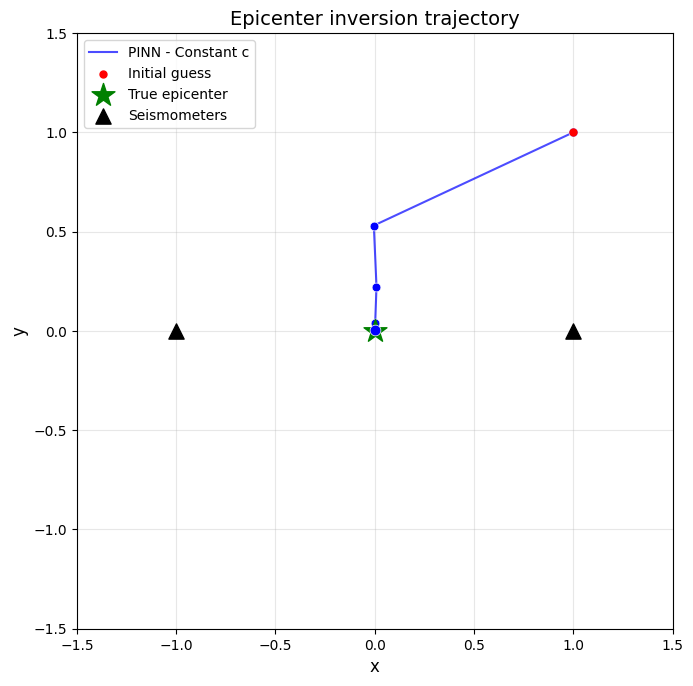

In [445]:
e_hat_pinn_const, _, _, history_pinn_const = inverse_function(
    forward=pinn_solver_const,
    traces_obs=traces_obs_constant, 
    dt=pinn_solver_const.dt,
    init=init_guess,
    steps=10, lr=1, max_iter=3,
    device="cpu",
)
history_pinn_const.insert(0, init_guess)
history_pinn = np.array(history_pinn_const)

print(f"True: ({true_ex}, {true_ey})")
print(f"Recovered: ({e_hat_pinn_const[0].item():.4f}, {e_hat_pinn_const[1].item():.4f})")
print(f"Error: {torch.norm(e_hat_pinn_const - torch.tensor([true_ex, true_ey])).item():.4f}")

plot_trajectories(history_pinn, (true_ex, true_ey), sensors_2.cpu(), labels=["PINN - Constant c"])
# e_hat_pinn_const, _, _, history_pinn_const = inverse_function(
#     forward=pinn_solver_const,
#     traces_obs=traces_pinn_const, 
#     dt=pinn_solver_const.dt,
#     init=init_guess,
#     steps=10, lr=1, max_iter=3,
#     device="cpu",
# )
# history_pinn_const.insert(0, init_guess)
# history_pinn = np.array(history_pinn_const)

# print(f"True: ({true_ex}, {true_ey})")
# print(f"Recovered: ({e_hat_pinn_const[0].item():.4f}, {e_hat_pinn_const[1].item():.4f})")
# print(f"Error: {torch.norm(e_hat_pinn_const - torch.tensor([true_ex, true_ey])).item():.4f}")

# plot_trajectories(history_pinn, (true_ex, true_ey), sensors_2.cpu(), labels=["PINN - Constant c"])

### Batch accuracy :

In [14]:
def run_inversion_batch(solver, epicenters, steps=10, lr=1, max_iter=3):
    errors = []
    for m in tqdm(range(len(epicenters))):
        ex, ey = epicenters[m, 0].item(), epicenters[m, 1].item()
        traces_obs = solver.forward(ex, ey).detach()
        e_hat, _, _, _ = inverse_function(
            forward=solver, traces_obs=traces_obs,
            dt=solver.dt, init=init_guess,
            steps=steps, lr=lr, max_iter=max_iter,
            device="cpu", show_progress=False,
        )
        err = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
        errors.append(err)
    return np.array(errors)

In [21]:
errors_const = run_inversion_batch(dp_const, epicenters)
errors_hetero = run_inversion_batch(dp_hetero, epicenters)

100%|██████████| 20/20 [07:25<00:00, 22.30s/it]


#### Y ambuiguity :

In [22]:
errors_const2 = run_inversion_batch(dp_const_asym,  epicenters)
errors_hetero2 = run_inversion_batch(dp_hetero_asym, epicenters)

100%|██████████| 20/20 [08:49<00:00, 26.47s/it]


In [18]:
errors_const_pinn = run_inversion_batch(pinn_solver_const, epicenters)
errors_const2_pinn = run_inversion_batch(pinn_solver_const_asym, epicenters)

100%|██████████| 20/20 [00:00<00:00, 24.82it/s]


In [23]:
print(f"{errors_const=}")
print(f"{errors_hetero=}")
print(f"{errors_const2=}")
print(f"{errors_hetero2=}")
print(f"{errors_const_pinn=}")
print(f"{errors_const2_pinn=}")

errors_const=array([0.00000000e+00, 1.53759360e+00, 1.75282860e+00, 3.89484024e+00,
       9.30002555e-02, 1.01852459e-06, 8.67856727e-07, 3.37174782e-07,
       2.98023224e-07, 3.73471928e+00, 3.68589330e+00, 3.24926662e+00,
       6.31496239e+00, 2.25899792e+00, 5.45521915e-01, 3.16385269e-01,
       5.96046448e-08, 2.59763694e+00, 4.17232513e-07, 4.85146643e-07])
errors_hetero=array([9.13970768e-01, 7.11349726e-01, 1.78781366e+00, 3.66201043e+00,
       6.43456602e+00, 5.09262293e-07, 6.41961662e-07, 4.33928363e-07,
       9.70293286e-07, 3.76754975e+00, 3.97598028e+00, 2.84672189e+00,
       6.86033869e+00, 1.06500518e+00, 8.07855034e+00, 6.80884218e+00,
       5.96046448e-08, 1.01645064e+00, 5.96046448e-08, 7.53945756e-07])
errors_const2=array([9.83024961e-07, 4.07626247e+00, 2.57774019e+00, 5.40242624e+00,
       5.66092670e-01, 4.80548010e-07, 4.80548010e-07, 2.66560079e-07,
       1.01327896e-06, 4.60318136e+00, 3.83350205e+00, 4.92272997e+00,
       6.76173735e+00, 1.51297688e

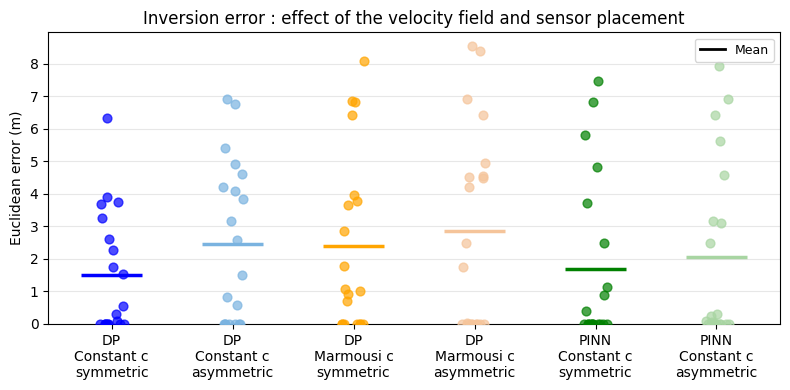

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

configs = ["DP\nConstant c\nsymmetric", "DP\nConstant c\nasymmetric", 
           "DP\nMarmousi c\nsymmetric", "DP\nMarmousi c\nasymmetric",
           "PINN\nConstant c\nsymmetric", "PINN\nConstant c\nasymmetric"]
           
all_errors = [errors_const, errors_const2, errors_hetero, errors_hetero2, errors_const_pinn, errors_const2_pinn]

for i, (errors, color) in enumerate(zip(all_errors, colors)):
    jitter = np.random.uniform(-0.1, 0.1, size=len(errors))
    ax.scatter(i + jitter, errors, color=color, s=40, alpha=0.7, zorder=5)
    ax.hlines(errors.mean(), i-0.25, i+0.25, color=color, linewidth=2.5, zorder=6)

ax.set_xticks(range(len(configs)))
ax.set_xticklabels(configs)
ax.set_ylim(bottom=0)
ax.set_title("Inversion error : effect of the velocity field and sensor placement")
ax.set_ylabel("Euclidean error (m)")
ax.grid(True, alpha=0.3, axis="y")

legend_elements = [
    Line2D([0], [0], color="black", linewidth=2, linestyle="-", label="Mean"),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

### Convergence trajectory : 

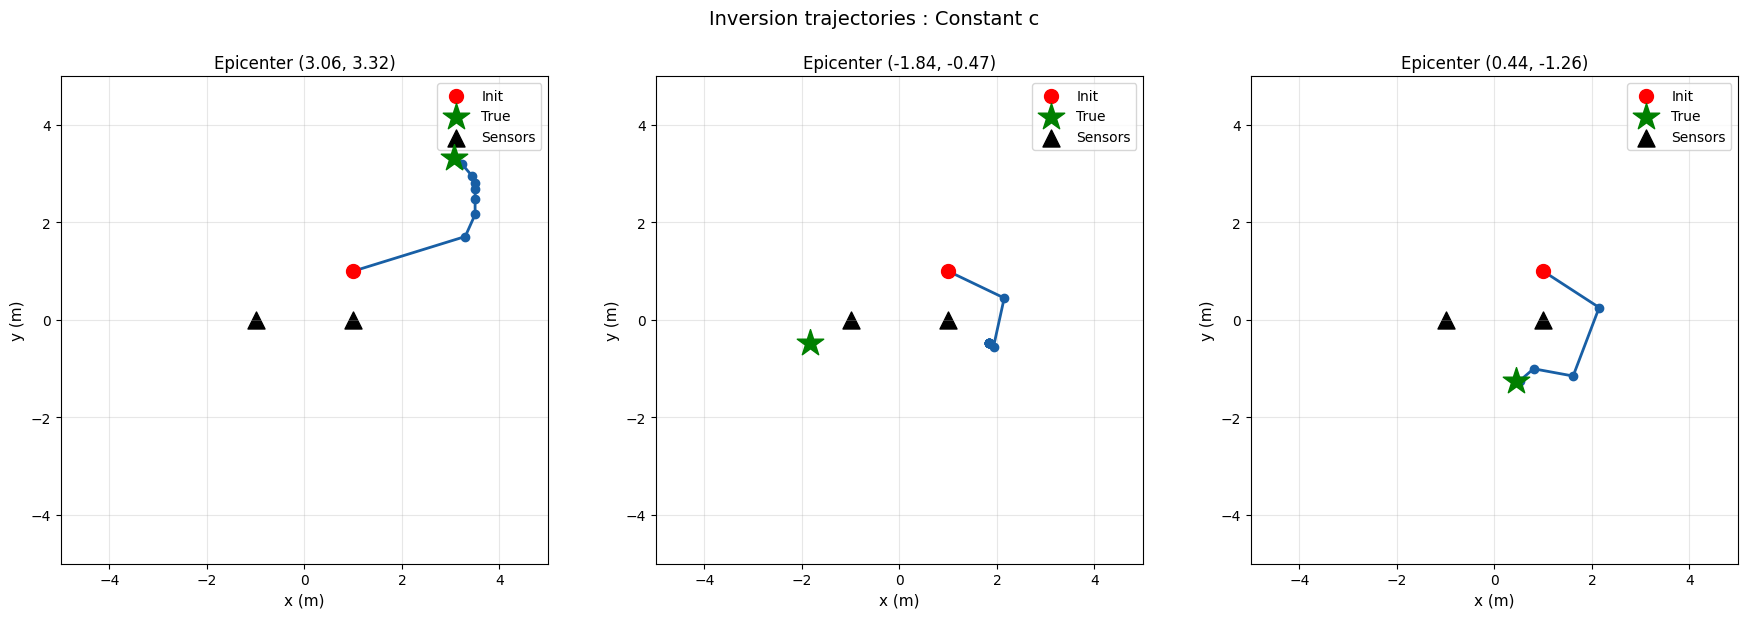

In [436]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sample_idx = [0, len(epicenters)//2, -1]

for ax, idx in zip(axes, sample_idx):
    ex, ey = epicenters[idx, 0].item(), epicenters[idx, 1].item()
    traces_obs = dp_const.forward(ex, ey).detach()
    _, _, _, history = inverse_function(
        forward=dp_const, traces_obs=traces_obs,
        dt=dp_const.dt, init=init_guess,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    history = np.array([init_guess] + history)
    ax.plot(history[:, 0], history[:, 1], "o-", color="#185FA5", linewidth=2, markersize=6)
    ax.scatter(*init_guess, color="red", s=100, zorder=5, label="Init")
    ax.scatter(ex, ey, marker="*", color="green", s=400, zorder=6, label="True")
    ax.scatter(sensors_2[:, 0], sensors_2[:, 1], marker="^", color="black", s=150, label="Sensors")
    ax.set_title(f"Epicenter ({ex:.2f}, {ey:.2f})", fontsize=12)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_xlabel("x (m)", fontsize=11)
    ax.set_ylabel("y (m)", fontsize=11)
    ax.tick_params(labelsize=10)

plt.suptitle("Inversion trajectories : Constant c", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

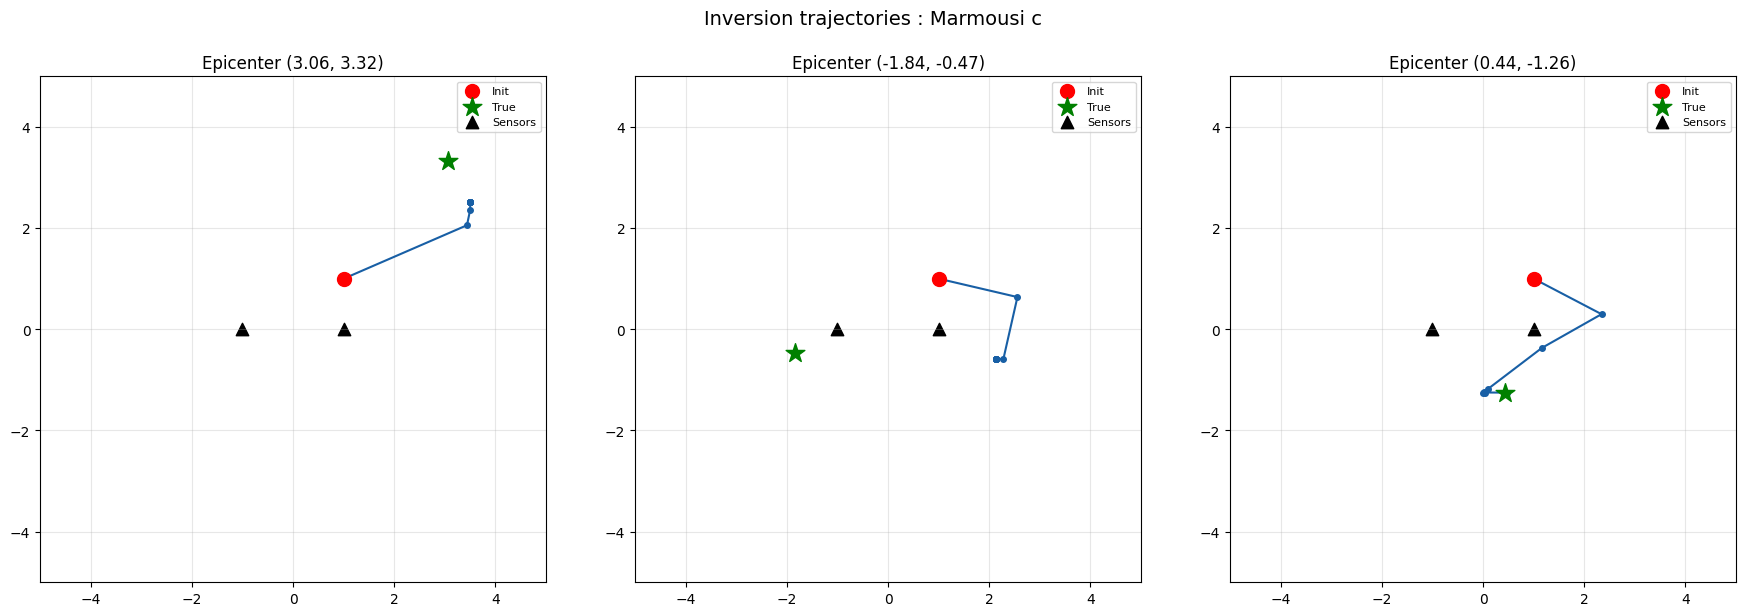

In [432]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sample_idx = [0, len(epicenters)//2, -1]

for ax, idx in zip(axes, sample_idx):
    ex, ey = epicenters[idx, 0].item(), epicenters[idx, 1].item()
    traces_obs = dp_hetero.forward(ex, ey).detach()
    _, _, _, history = inverse_function(
        forward=dp_hetero, traces_obs=traces_obs,
        dt=dp_hetero.dt, init=init_guess,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    history = np.array([init_guess] + history)
    ax.plot(history[:, 0], history[:, 1], "o-", color="#185FA5", linewidth=1.5, markersize=4)
    ax.scatter(*init_guess, color="red", s=100, zorder=5, label="Init")
    ax.scatter(ex, ey, marker="*", color="green", s=200, zorder=6, label="True")
    ax.scatter(sensors_2[:, 0], sensors_2[:, 1], marker="^", color="black", s=80, label="Sensors")
    ax.set_title(f"Epicenter ({ex:.2f}, {ey:.2f})")
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Inversion trajectories : Marmousi c", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

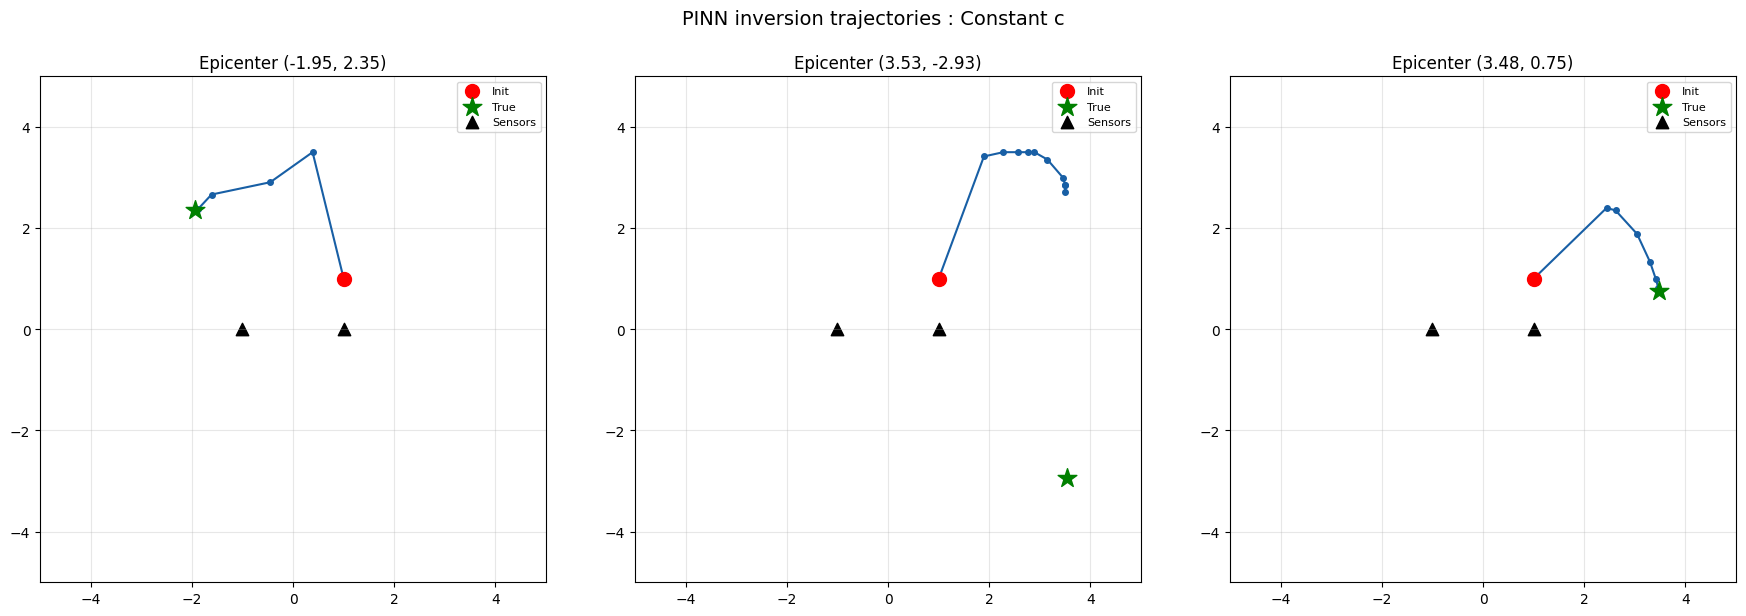

In [453]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ok=3
sample_idx = [0+ok,1+ok,2+ok]

for ax, idx in zip(axes, sample_idx):
    ex, ey = epicenters[idx, 0].item(), epicenters[idx, 1].item()
    traces_obs = pinn_solver_const.forward(ex, ey).detach()
    _, _, _, history = inverse_function(
        forward=pinn_solver_const, traces_obs=traces_obs,
        dt=pinn_solver_const.dt, init=init_guess,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    history = np.array([init_guess] + history)
    ax.plot(history[:, 0], history[:, 1], "o-", color="#185FA5", linewidth=1.5, markersize=4)
    ax.scatter(*init_guess, color="red", s=100, zorder=5, label="Init")
    ax.scatter(ex, ey, marker="*", color="green", s=200, zorder=6, label="True")
    ax.scatter(sensors_2[:, 0], sensors_2[:, 1], marker="^", color="black", s=80, label="Sensors")
    ax.set_title(f"Epicenter ({ex:.2f}, {ey:.2f})")
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("PINN inversion trajectories : Constant c", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Effect of number of sensors :

In [ ]:
results_by_k = {2: errors_hetero}
for k, sensors_k in [(3, sensors_3), (4, sensors_4)]:
    solver_k = make_dp(sensors_k, c_marmousi)
    errors_k = run_inversion_batch(solver_k, epicenters)
    results_by_k[k] = errors_k
    print(f"K={k} — mean: {errors_k.mean():.4f}  std: {errors_k.std():.4f}")
print(f"{results_by_k=}")

100%|██████████| 20/20 [07:19<00:00, 21.97s/it]


K=3 — mean: 2.2994  std: 3.0739


100%|██████████| 20/20 [07:02<00:00, 21.14s/it]

K=4 — mean: 1.8601  std: 2.9235


In [26]:
results_by_k_pinn_const = {2: errors_const_pinn}
for k, sensors_k in [(3, sensors_3), (4, sensors_4)]:
    solver_k_pinn = make_pinn(sensors_k, model_pinn_const)
    errors_k_pinn = run_inversion_batch(solver_k_pinn, epicenters)
    results_by_k_pinn_const[k] = errors_k_pinn
    print(f"K={k} — mean: {errors_k_pinn.mean():.4f}  std: {errors_k_pinn.std():.4f}")
print(f"{results_by_k_pinn_const=}")

100%|██████████| 20/20 [00:01<00:00, 15.09it/s]


K=3 — mean: 1.6343  std: 2.6195


100%|██████████| 20/20 [00:01<00:00, 12.46it/s]

K=4 — mean: 0.6237  std: 1.5857
results_by_k_pinn_const={2: array([2.98737632e-06, 4.00456578e-01, 7.83976702e-07, 3.57627869e-07,
       5.79281092e+00, 5.96046448e-08, 2.27749024e-06, 1.12114131e+00,
       8.84260589e-06, 3.37174782e-07, 8.77551913e-01, 4.76837158e-07,
       3.72711039e+00, 4.81854677e+00, 7.45558071e+00, 6.80692482e+00,
       6.42957048e-06, 2.56784665e-06, 1.19209290e-07, 2.49894309e+00]), 3: array([1.59936042e-06, 2.38200992e-01, 5.96046448e-08, 4.29815202e-07,
       6.38873816e+00, 3.57627869e-07, 4.17232513e-07, 3.76972878e-07,
       1.92219204e-06, 4.29815202e-07, 2.08382225e+00, 3.37174782e-07,
       5.40289497e+00, 6.34541368e+00, 5.32823706e+00, 6.89878941e+00,
       1.43051147e-06, 0.00000000e+00, 1.19209290e-07, 6.41961662e-07]), 4: array([2.38418579e-07, 4.34895128e-01, 1.33280039e-07, 5.33120158e-07,
       2.82888580e-02, 1.78813934e-07, 2.66560079e-07, 1.68587391e-07,
       5.96046448e-07, 1.19209290e-07, 4.18048614e-04, 0.00000000e+00,
       

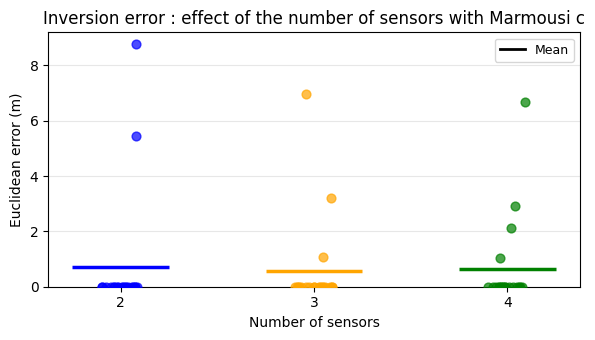

In [167]:
COLOR_K2 = "blue"  # blue
COLOR_K3 = "orange"  # orange  
COLOR_K4 = "green"  # green

colors = [COLOR_K2, COLOR_K3, COLOR_K4]
labels = ["2", "3", "4"]

fig, ax = plt.subplots(figsize=(6, 3.5))

for i, (k, color) in enumerate(zip([2, 3, 4], colors)):
    errors = results_by_k[k]
    jitter = np.random.uniform(-0.1, 0.1, size=len(errors))
    ax.scatter(i + jitter, errors, color=color, s=40, alpha=0.7, zorder=5)
    ax.hlines(errors.mean(), i-0.25, i+0.25, color=color, linewidth=2.5, zorder=6)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylim(bottom=0)
ax.set_title("Inversion error : effect of the number of sensors with Marmousi c")
ax.set_ylabel("Euclidean error (m)")
ax.set_xlabel("Number of sensors")
ax.grid(True, alpha=0.3, axis="y")
ax.legend(handles=[Line2D([0], [0], color="black", linewidth=2, label="Mean")], fontsize=9)
plt.tight_layout()
plt.show()

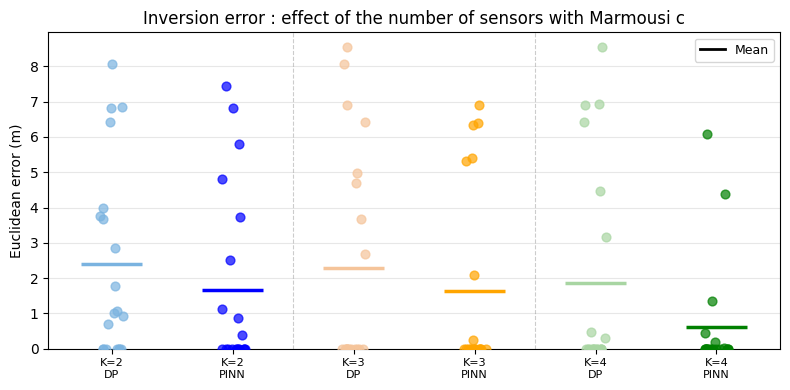

In [29]:
COLOR_K2_DP   = "blue"
COLOR_K3_DP   = "orange"
COLOR_K4_DP   = "green"
COLOR_K2_PINN ="#7AB3E0"
COLOR_K3_PINN = "#F5C49A"
COLOR_K4_PINN = "#A8D5A2"

configs = ["K=2\nDP", "K=2\nPINN", 
           "K=3\nDP", "K=3\nPINN", 
           "K=4\nDP", "K=4\nPINN"]

all_errors = [
    results_by_k[2], results_by_k_pinn_const[2], 
    results_by_k[3], results_by_k_pinn_const[3], 
    results_by_k[4], results_by_k_pinn_const[4]
]

colors = [
    COLOR_K2_PINN, COLOR_K2_DP,
    COLOR_K3_PINN, COLOR_K3_DP,
    COLOR_K4_PINN, COLOR_K4_DP,
]

fig, ax = plt.subplots(figsize=(8, 4))

for i, (errors, color) in enumerate(zip(all_errors, colors)):
    jitter = np.random.uniform(-0.1, 0.1, size=len(errors))
    ax.scatter(i + jitter, errors, color=color, s=40, alpha=0.7, zorder=5)
    ax.hlines(errors.mean(), i-0.25, i+0.25, color=color, linewidth=2.5, zorder=6)

# vertical separators between K groups
for x in [1.5, 3.5]:
    ax.axvline(x, color="gray", linewidth=0.8, linestyle="--", alpha=0.4)

ax.set_xticks(range(len(configs)))
ax.set_xticklabels(configs, fontsize=8)
ax.set_ylim(bottom=0)
ax.set_title("Inversion error : effect of the number of sensors with Marmousi c")
ax.set_ylabel("Euclidean error (m)")
ax.grid(True, alpha=0.3, axis="y")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="black", linewidth=2, label="Mean"),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

### Sensitivity to initial guess : 

In [30]:
# Computation cell (run once)
ex_test, ey_test = 1.5, 1.0
traces_obs = dp_hetero.forward(ex_test, ey_test).detach()
inits = [(-3,-3), (-3,3), (3,-3), (3,3), (0,0), (1,1)]

init_histories = {}
for init in tqdm(inits):
    _, _, _, history = inverse_function(
        forward=dp_hetero, traces_obs=traces_obs,
        dt=dp_hetero.dt, init=init,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    init_histories[init] = np.array([init] + history)

100%|██████████| 6/6 [02:18<00:00, 23.03s/it]


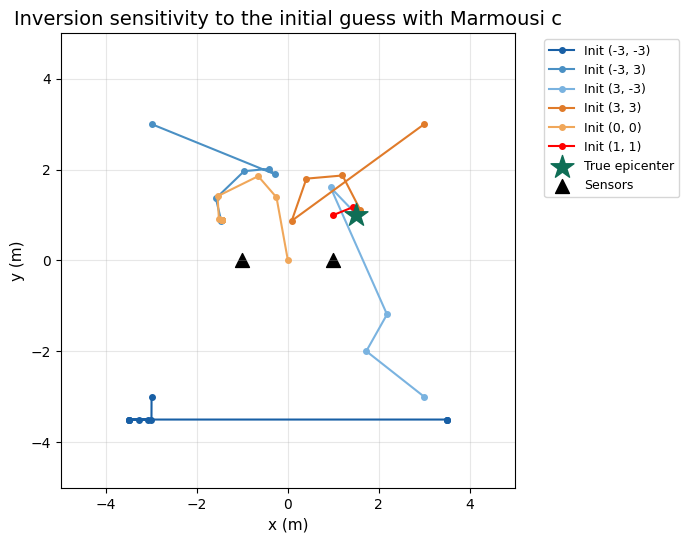

In [31]:
colors = [
    "#185FA5",  # dark blue
    "#4A90C4",  # medium blue
    "#7AB3E0",  # light blue
    "#E07B2A",  # dark orange
    "#F0A75A",  # medium orange
    "red",  # light orange
]

fig, ax = plt.subplots(figsize=(7, 7))
for (init, history), color in zip(init_histories.items(), colors):
    ax.plot(history[:, 0], history[:, 1], "o-", color=color,
            linewidth=1.5, markersize=4, label=f"Init {init}")

ax.scatter(ex_test, ey_test, marker="*", color="#0F6E56", s=300, zorder=6, label="True epicenter")
ax.scatter(sensors_2[:, 0], sensors_2[:, 1], marker="^", color="black", s=100, label="Sensors")
ax.set_title(f"Inversion sensitivity to the initial guess with Marmousi c", fontsize=14)
ax.set_xlabel("x (m)", fontsize=11)
ax.set_ylabel("y (m)", fontsize=11)
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [32]:
# Computation cell (run once)
ex_test, ey_test = 1.5, 1.0
traces_obs_pinn = pinn_solver_const.forward(ex_test, ey_test).detach()
inits = [(-3,-3), (-3,3), (3,-3), (3,3), (0,0), (1,1)]

init_histories_pinn_const = {}
for init in tqdm(inits):
    _, _, _, history = inverse_function(
        forward=pinn_solver_const, traces_obs=traces_obs_pinn,
        dt=pinn_solver_const.dt, init=init,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    init_histories_pinn_const[init] = np.array([init] + history)

100%|██████████| 6/6 [00:00<00:00, 15.68it/s]


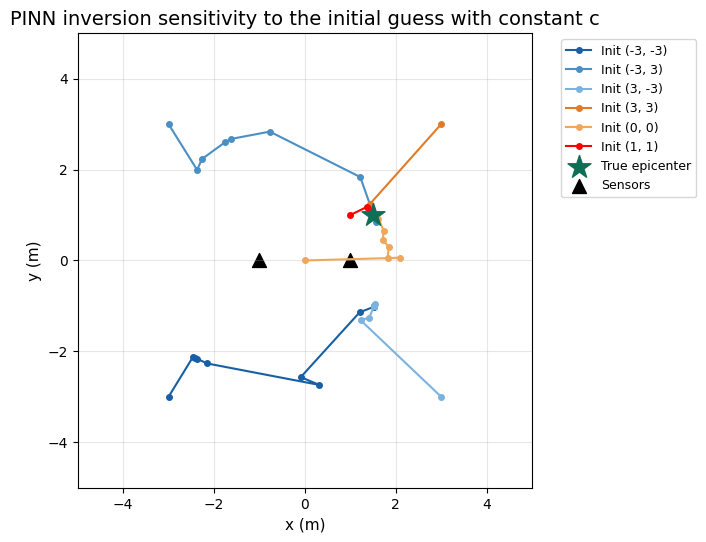

In [33]:
colors = [
    "#185FA5",  # dark blue
    "#4A90C4",  # medium blue
    "#7AB3E0",  # light blue
    "#E07B2A",  # dark orange
    "#F0A75A",  # medium orange
    "red",  # light orange
]

fig, ax = plt.subplots(figsize=(7, 7))
for (init, history), color in zip(init_histories_pinn_const.items(), colors):
    ax.plot(history[:, 0], history[:, 1], "o-", color=color,
            linewidth=1.5, markersize=4, label=f"Init {init}")

ax.scatter(ex_test, ey_test, marker="*", color="#0F6E56", s=300, zorder=6, label="True epicenter")
ax.scatter(sensors_2[:, 0], sensors_2[:, 1], marker="^", color="black", s=100, label="Sensors")
ax.set_title(f"PINN inversion sensitivity to the initial guess with constant c", fontsize=14)
ax.set_xlabel("x (m)", fontsize=11)
ax.set_ylabel("y (m)", fontsize=11)
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Error heatmap :

In [34]:
grid_n = 6  # reduced to save time
gx = np.linspace(-4, 4, grid_n)
gy = np.linspace(-4, 4, grid_n)
GX, GY = np.meshgrid(gx, gy)

error_maps = {}
for solver, label in [(dp_const, "Constant c"), (dp_hetero, "Heterogeneous c")]:
    error_map = np.zeros((grid_n, grid_n))
    for i in range(grid_n):
        print(f"Processing {label} — Row {i+1}/{grid_n}")
        for j in range(grid_n):
            ex, ey = float(GX[i,j]), float(GY[i,j])
            traces_obs = solver.forward(ex, ey).detach()
            e_hat, _, _, _ = inverse_function(
                forward=solver, traces_obs=traces_obs,
                dt=solver.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            error_map[i,j] = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
    error_maps[label] = error_map
print(f"{error_maps=}")


Processing Constant c — Row 1/6
Processing Constant c — Row 2/6
Processing Constant c — Row 3/6
Processing Constant c — Row 4/6
Processing Constant c — Row 5/6
Processing Constant c — Row 6/6
Processing Heterogeneous c — Row 1/6
Processing Heterogeneous c — Row 2/6
Processing Heterogeneous c — Row 3/6
Processing Heterogeneous c — Row 4/6
Processing Heterogeneous c — Row 5/6
Processing Heterogeneous c — Row 6/6
error_maps={'Constant c': array([[7.51664829e+00, 4.64347649e+00, 2.26526046e+00, 7.88263679e-01,
        5.32626987e-01, 7.07106769e-01],
       [7.57185555e+00, 4.80000019e+00, 1.60000038e+00, 3.57627869e-07,
        7.15255737e-07, 1.15456581e+00],
       [7.73840141e+00, 4.80000019e+00, 1.60000086e+00, 6.95103608e-07,
        1.01327896e-06, 1.97059977e+00],
       [7.89546204e+00, 4.80000067e+00, 1.59999967e+00, 2.14907601e-07,
        1.39530891e-06, 2.51760864e+00],
       [7.52668905e+00, 4.80000067e+00, 1.60000050e+00, 2.45756240e-07,
        2.38418579e-07, 8.06876659e-

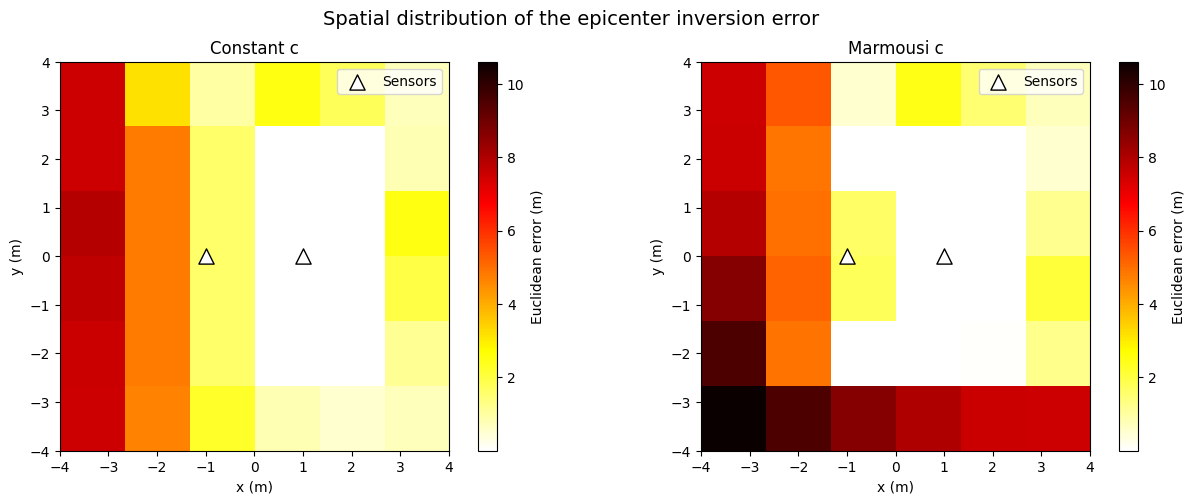

In [35]:
vmin = min(m.min() for m in error_maps.values())
vmax = max(m.max() for m in error_maps.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ims = []
titles = ["Constant c", "Marmousi c"]
for ax, title, (label, error_map) in zip(axes, titles, error_maps.items()):
    im = ax.imshow(error_map, extent=[-4,4,-4,4], origin="lower",
                   cmap="hot_r", aspect="equal", vmin=vmin, vmax=vmax)
    ims.append(im)
    ax.scatter(sensors_2[:,0], sensors_2[:,1], marker="^", color="white",
               edgecolors="black", s=120, zorder=5, label="Sensors")
    ax.set_title(f"{title}")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="upper right")
    plt.colorbar(im, ax=ax, label="Euclidean error (m)")

plt.suptitle("Spatial distribution of the epicenter inversion error", fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
grid_n = 6  # reduced to save time
gx = np.linspace(-4, 4, grid_n)
gy = np.linspace(-4, 4, grid_n)
GX, GY = np.meshgrid(gx, gy)

error_maps_pinn = {}
for solver, label in [(pinn_solver_const, "Constant c"), (pinn_solver_const, "Constant c")]:
    error_map = np.zeros((  grid_n, grid_n))
    for i in range(grid_n):
        # print(f"Processing {label} — Row {i+1}/{grid_n}")
        for j in range(grid_n):
            ex, ey = float(GX[i,j]), float(GY[i,j])
            traces_obs = solver.forward(ex, ey).detach()
            e_hat, _, _, _ = inverse_function(
                forward=solver, traces_obs=traces_obs,
                dt=solver.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            error_map[i,j] = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
    error_maps_pinn[label] = error_map
print(f"{error_maps_pinn=}")

error_maps_pinn={'Constant c': array([[1.03018684e+01, 7.52896833e+00, 7.57361650e+00, 7.83294392e+00,
        7.52261400e+00, 7.51664829e+00],
       [6.04777384e+00, 4.82734966e+00, 4.80934858e+00, 4.78080750e+00,
        4.75959539e+00, 8.55684876e-01],
       [1.87987137e+00, 1.47271049e+00, 1.59819615e+00, 1.57620871e+00,
        1.55103517e+00, 1.21081626e+00],
       [6.11022472e-01, 1.97416489e-06, 1.88486439e-07, 8.42936956e-08,
        5.96046448e-08, 6.19611025e-01],
       [1.64922011e+00, 3.37174782e-07, 7.74860382e-07, 4.29815202e-07,
        5.33120158e-07, 2.11651826e+00],
       [7.51664829e+00, 7.47345984e-01, 1.22099006e+00, 1.18956327e+00,
        8.08698297e-01, 7.07106769e-01]])}


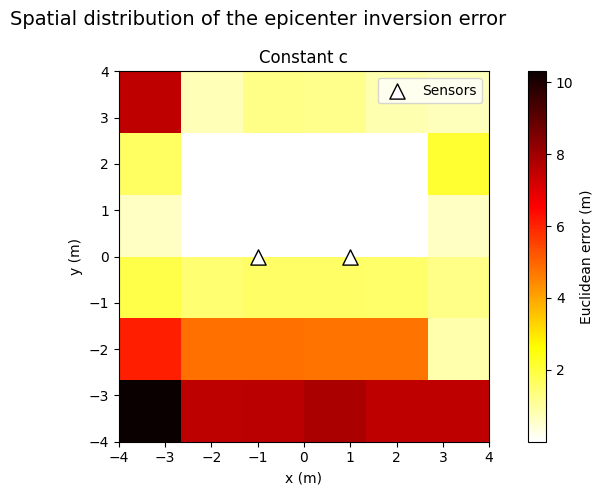

In [37]:
vmin_pinn = min(m.min() for m in error_maps_pinn.values())
vmax_pinn = max(m.max() for m in error_maps_pinn.values())

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ims = []
titles = ["Constant c"]
for title, (label, error_map) in zip(titles, error_maps_pinn.items()):
    im = ax.imshow(error_map, extent=[-4,4,-4,4], origin="lower",
                   cmap="hot_r", aspect="equal", vmin=vmin_pinn, vmax=vmax_pinn)
    ims.append(im)
    ax.scatter(sensors_2[:,0], sensors_2[:,1], marker="^", color="white",
               edgecolors="black", s=120, zorder=5, label="Sensors")
    ax.set_title(f"{title}")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="upper right")
    plt.colorbar(im, ax=ax, label="Euclidean error (m)")

plt.suptitle("Spatial distribution of the epicenter inversion error", fontsize=14)
plt.tight_layout()
plt.show()

### Noise robustness : 

In [38]:
noise_levels = [0.0, 0.01, 0.05, 0.1]
ex_test, ey_test = 1.5, -1.0
noise_results = {}

for solver, label, color in [(dp_const, "Constant c", "blue"), (dp_hetero, "Marmousi c", "orange")]:
    traces_clean = solver.forward(ex_test, ey_test).detach()
    mean_errors, std_errors = [], []
    for sigma_n in noise_levels:
        errs = []
        for _ in range(10):
            noise = torch.randn_like(traces_clean) * sigma_n * traces_clean.std(dim=0)
            e_hat, _, _, _ = inverse_function(
                forward=solver, traces_obs=traces_clean + noise,
                dt=solver.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            errs.append(((e_hat[0]-ex_test)**2 + (e_hat[1]-ey_test)**2).sqrt().item())
        mean_errors.append(np.mean(errs))
        std_errors.append(np.std(errs))
    noise_results[label] = {"mean": mean_errors, "std": std_errors, "color": color}
print(f"{noise_results=}")

noise_results={'Constant c': {'mean': [np.float64(2.4575624024691933e-07), np.float64(0.0008803107142739463), np.float64(0.004210960853379219), np.float64(0.010005953954532743)], 'std': [np.float64(0.0), np.float64(0.0004810416638445372), np.float64(0.0019638126385262233), np.float64(0.003593863308871792)], 'color': 'blue'}, 'Marmousi c': {'mean': [np.float64(9.310543305218744e-07), np.float64(0.0008556223008781671), np.float64(0.005044185498263687), np.float64(0.0070089940447360275)], 'std': [np.float64(0.0), np.float64(0.0004884866372811528), np.float64(0.002554000381906741), np.float64(0.00422314134960107)], 'color': 'orange'}}


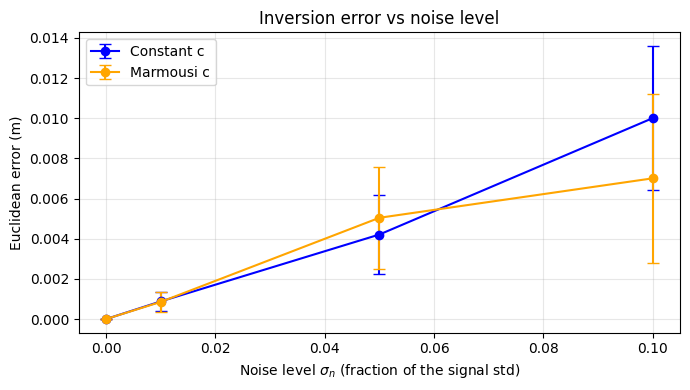

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))

for label, data in noise_results.items():
    ax.errorbar(noise_levels, data["mean"], yerr=data["std"],
                marker="o", linewidth=1.5, capsize=4,
                color=data["color"], label=label)

ax.set_title("Inversion error vs noise level")
ax.set_xlabel("Noise level $\\sigma_n$ (fraction of the signal std)")
ax.set_ylabel("Euclidean error (m)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [478]:
for label, data in noise_results.items():
    print(f"{label}: {list(zip(noise_levels, data['mean'], data['std']))}")

Constant c: [(0.0, np.float64(2.4575624024691933e-07), np.float64(0.0)), (0.01, np.float64(0.0007993311941390857), np.float64(0.00039429077269326424)), (0.05, np.float64(0.00433636010857299), np.float64(0.0022175167098017626)), (0.1, np.float64(0.008070581126958132), np.float64(0.002465914171186672))]
Marmousi c: [(0.0, np.float64(9.310543305218744e-07), np.float64(0.0)), (0.01, np.float64(0.0008224703618907369), np.float64(0.0004099816624985334)), (0.05, np.float64(0.004143602808471769), np.float64(0.0015980566866929944)), (0.1, np.float64(0.010707279318012297), np.float64(0.00556351332642906))]


In [43]:
noise_levels = [0.0, 0.01, 0.05, 0.1]
ex_test, ey_test = 1.5, -1.0
noise_results_pinn = {}

for solver, label, color in [(pinn_solver_const, "Constant c", "blue")]:#, (pinn_solver_const, "Marmousi c", "orange")]:
    traces_clean = solver.forward(ex_test, ey_test).detach()
    mean_errors, std_errors = [], []
    for sigma_n in noise_levels:
        errs = []
        for _ in range(10):
            noise = torch.randn_like(traces_clean) * sigma_n * traces_clean.std(dim=0)
            e_hat, _, _, _ = inverse_function(
                forward=solver, traces_obs=traces_clean + noise,
                dt=solver.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            errs.append(((e_hat[0]-ex_test)**2 + (e_hat[1]-ey_test)**2).sqrt().item())
        mean_errors.append(np.mean(errs))
        std_errors.append(np.std(errs))
    noise_results_pinn[label] = {"mean": mean_errors, "std": std_errors, "color": color}
print(f"{noise_results_pinn=}")

noise_results_pinn={'Constant c': {'mean': [np.float64(1.989784836769104), np.float64(1.9891735792160035), np.float64(1.9911796569824218), np.float64(1.9933707118034363)], 'std': [np.float64(0.0), np.float64(0.0012556991624079032), np.float64(0.008144326988277955), np.float64(0.011702973936421685)], 'color': 'blue'}}


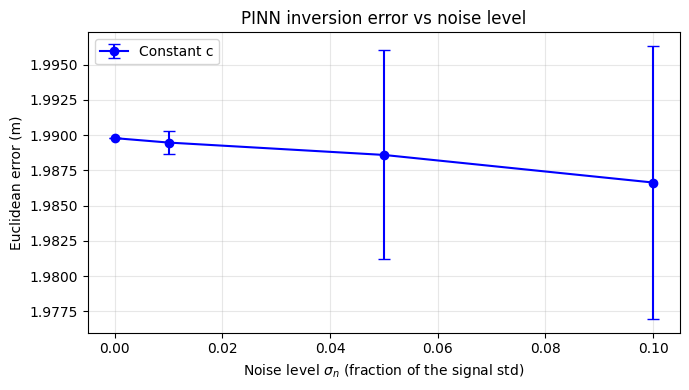

In [41]:
fig, ax = plt.subplots(figsize=(7, 4))

for label, data in noise_results_pinn.items():
    ax.errorbar(noise_levels, data["mean"], yerr=data["std"],
                marker="o", linewidth=1.5, capsize=4,
                color=data["color"], label=label)

ax.set_title("PINN inversion error vs noise level")
ax.set_xlabel("Noise level $\\sigma_n$ (fraction of the signal std)")
ax.set_ylabel("Euclidean error (m)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Runtime benchmark : 

In [376]:
import time

traces_obs = dp_hetero.forward(0, 0).detach()
n_runs = 5

times_fwd, times_inv = [], []
for _ in tqdm(range(n_runs)):
    t0 = time.perf_counter()
    dp_hetero.forward(0, 0)
    times_fwd.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    inverse_function(
        forward=dp_hetero, traces_obs=traces_obs,
        dt=dp_hetero.dt, init=init_guess,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    times_inv.append(time.perf_counter() - t0)

print(f"DP forward   — mean: {np.mean(times_fwd):.3f}s  std: {np.std(times_fwd):.3f}s")
print(f"DP inversion — mean: {np.mean(times_inv):.3f}s  std: {np.std(times_inv):.3f}s")

100%|██████████| 5/5 [01:33<00:00, 18.64s/it]

DP forward   — mean: 0.241s  std: 0.014s
DP inversion — mean: 18.394s  std: 0.290s


In [44]:
import time

traces_obs = pinn_solver_const.forward(0, 0).detach()
n_runs = 5

times_fwd, times_inv = [], []
for _ in tqdm(range(n_runs)):
    t0 = time.perf_counter()
    pinn_solver_const.forward(0, 0)
    times_fwd.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    inverse_function(
        forward=pinn_solver_const, traces_obs=traces_obs,
        dt=pinn_solver_const.dt, init=init_guess,
        steps=10, lr=1, max_iter=3,
        device="cpu", show_progress=False,
    )
    times_inv.append(time.perf_counter() - t0)

print(f"PINN forward   — mean: {np.mean(times_fwd):.3f}s  std: {np.std(times_fwd):.3f}s")
print(f"PINN inversion — mean: {np.mean(times_inv):.3f}s  std: {np.std(times_inv):.3f}s")

100%|██████████| 5/5 [00:00<00:00, 22.92it/s]

PINN forward   — mean: 0.001s  std: 0.000s
PINN inversion — mean: 0.042s  std: 0.004s


### Sensors placement : 

In [ ]:
torch.manual_seed(42)
N_EPI_OPT = 20
epicenters_opt = torch.rand(N_EPI_OPT, 2) * 8 - 4  # uniform in [-4, 4]^2


# Step 1: optimize with PINN
sensors_opt_pinn, history = optimize_sensors(
    pinn_model=model_pinn_const,
    sensors_init=sensors_2.clone(),
    epicenters=epicenters_opt,
    inner_steps=1, inner_lr=0.05,
    outer_steps=100, outer_lr=0.01,
    device="cpu",
)

# Step 2: local search with PINN
sensors_best, best_loss = local_search(
    pinn_model=model_pinn_const,
    sensors_best=sensors_opt_pinn,
    epicenters=epicenters_opt,
    n_neighbors=10,
    device="cpu",
)

Initial sensors: [[-1.  0.]
 [ 1.  0.]]
sensors.grad after backward: tensor([[ 0.7860,  0.2281],
        [-0.2127,  1.1405]])
grad norm: 1.4197661876678467
Step   0 | Outer loss: 14.0481 | Sensors: [[-1.01 -0.01]
 [ 1.01 -0.01]]
Step  10 | Outer loss: 13.7738 | Sensors: [[-1.1096259  -0.10873619]
 [ 1.1114498  -0.11109638]]
Step  20 | Outer loss: 13.4666 | Sensors: [[-1.2081493  -0.20067811]
 [ 1.2176088  -0.21537793]]
Step  30 | Outer loss: 13.1521 | Sensors: [[-1.3057672  -0.27849582]
 [ 1.327041   -0.3216808 ]]
Step  40 | Outer loss: 12.8592 | Sensors: [[-1.402993   -0.33527067]
 [ 1.4336121  -0.42686942]]
Step  50 | Outer loss: 12.6017 | Sensors: [[-1.5001312  -0.36593056]
 [ 1.5302488  -0.5282594 ]]
Step  60 | Outer loss: 12.3742 | Sensors: [[-1.5973426  -0.36791635]
 [ 1.6141553  -0.62506515]]
Step  70 | Outer loss: 12.1642 | Sensors: [[-1.6949413  -0.3415921 ]
 [ 1.6890366  -0.71802515]]
Step  80 | Outer loss: 11.9607 | Sensors: [[-1.7934633  -0.29029337]
 [ 1.7627482  -0.808223

In [331]:
# Step 3: evaluate with DP as ground truth
print(f"Initial sensors:   {sensors_2.numpy()}")
print(f"Optimized sensors: {sensors_best.numpy()}")

err_opt_pinn = run_inversion_batch(make_pinn(sensors_best,model_pinn_const), epicenters)
err_opt_dp = run_inversion_batch(make_dp(sensors_best, c_constant), epicenters)

print(f"Initial DP:     mean={errors_const.mean():.4f}")
print(f"Initial PINN:   mean={errors_const_pinn.mean():.4f}")
print(f"PINN optimized: mean={err_opt_pinn.mean():.4f}")
print(f"DP optimized:   mean={err_opt_dp.mean():.4f}")


Initial sensors:   [[-1.  0.]
 [ 1.  0.]]
Optimized sensors: [[-2.6127543 -3.5      ]
 [ 3.5       -1.5511492]]


100%|██████████| 20/20 [05:01<00:00, 15.09s/it]

Initial DP:     mean=1.4849
Initial PINN:   mean=1.6697
PINN optimized: mean=0.4324
DP optimized:   mean=0.0000


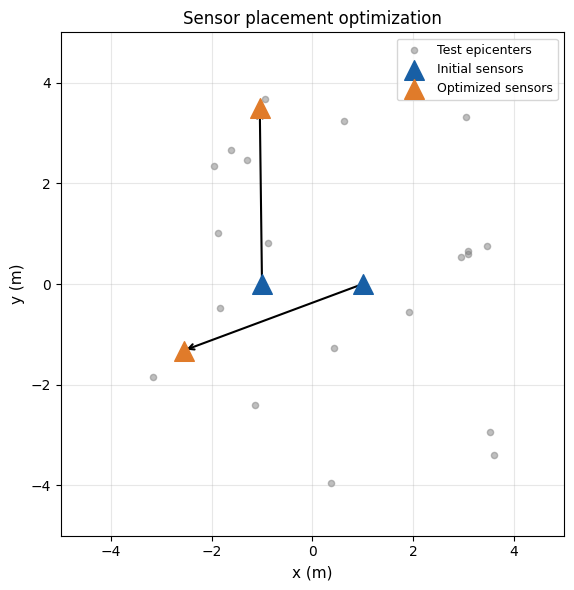

In [316]:
fig, ax = plt.subplots(figsize=(6, 6))

# domain boundary
ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)

# epicenters used for evaluation
ax.scatter(epicenters[:, 0], epicenters[:, 1], 
           color="gray", s=20, alpha=0.5, label="Test epicenters")

# initial sensors
ax.scatter(sensors_2[:, 0], sensors_2[:, 1], 
           marker="^", color="#185FA5", s=200, zorder=5, label="Initial sensors")

# optimized sensors
ax.scatter(sensors_best[:, 0].numpy(), sensors_best[:, 1].numpy(), 
           marker="^", color="#E07B2A", s=200, zorder=5, label="Optimized sensors")

# draw arrows from initial to optimized
for i in range(len(sensors_2)):
    ax.annotate("", 
        xy=(sensors_best[i, 0].item(), sensors_best[i, 1].item()),
        xytext=(sensors_2[i, 0].item(), sensors_2[i, 1].item()),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5))

ax.set_xlabel("x (m)", fontsize=11)
ax.set_ylabel("y (m)", fontsize=11)
ax.set_title("Sensor placement optimization")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("sensor_placement_opt.png", dpi=150, bbox_inches="tight")
plt.show()

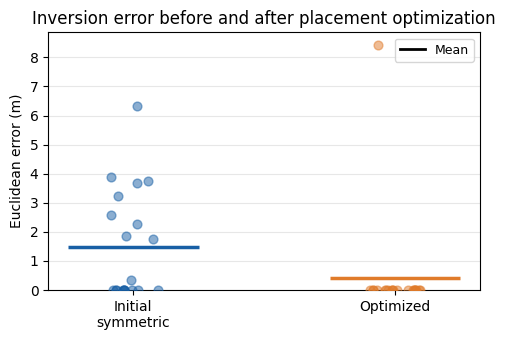

In [329]:
configs = ["Initial\nsymmetric", "Optimized"]
means = [errors_const.mean(), err_opt_dp.mean()]
stds  = [errors_const.std(),  err_opt_dp.std()]
colors = ["#185FA5", "#E07B2A"]

fig, ax = plt.subplots(figsize=(5, 3.5))
for i, (config, mean, std, color) in enumerate(zip(configs, means, stds, colors)):
    jitter = np.random.uniform(-0.1, 0.1, 
              size=len(errors_const if i==0 else err_opt_dp))
    errors = errors_const if i == 0 else err_opt_dp
    ax.scatter(i + jitter, errors, color=color, s=40, alpha=0.5, zorder=5)
    ax.hlines(mean, i-0.25, i+0.25, color=color, linewidth=2.5, zorder=6)

ax.set_xticks([0, 1])
ax.set_xticklabels(configs)
ax.set_ylim(bottom=0)
ax.set_ylabel("Euclidean error (m)")
ax.set_title("Inversion error before and after placement optimization")
ax.grid(True, alpha=0.3, axis="y")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], color="black", linewidth=2, label="Mean")],
          fontsize=9)
plt.tight_layout()
# plt.savefig("placement_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [325]:
# Computation cell
grid_n = 6
gx = np.linspace(-4, 4, grid_n)
gy = np.linspace(-4, 4, grid_n)
GX, GY = np.meshgrid(gx, gy)

error_maps_placement = {}
for sensors_k, label in [(sensors_2, "Initial symmetric"), 
                          (sensors_best, "Optimized")]:
    pinn_k = make_pinn(sensors_k, model_pinn_const)
    error_map = np.zeros((grid_n, grid_n))
    for i in range(grid_n):
        for j in range(grid_n):
            ex, ey = float(GX[i,j]), float(GY[i,j])
            traces_obs = pinn_k.forward(ex, ey).detach()
            e_hat, _, _, _ = inverse_function(
                forward=pinn_k, traces_obs=traces_obs,
                dt=pinn_k.dt, init=init_guess,
                steps=10, lr=1, max_iter=3,
                device="cpu", show_progress=False,
            )
            error_map[i,j] = ((e_hat[0]-ex)**2 + (e_hat[1]-ey)**2).sqrt().item()
    error_maps_placement[label] = (error_map, sensors_k)

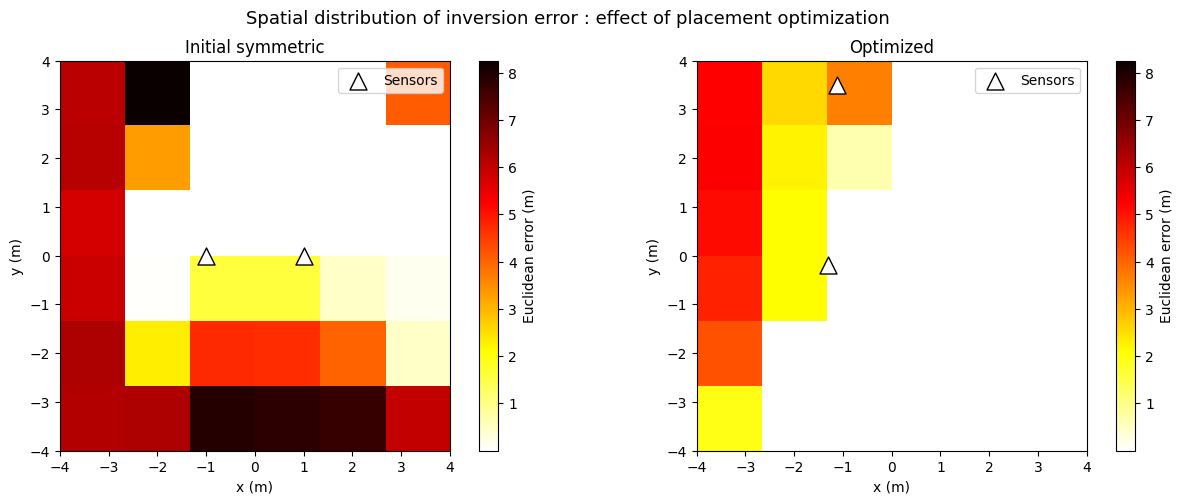

In [ ]:
# Plot cell
vmin3 = min(m.min() for m, _ in error_maps_placement.values())
vmax3 = max(m.max() for m, _ in error_maps_placement.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, (error_map, sensors_k)) in zip(axes, error_maps_placement.items()):
    im = ax.imshow(error_map, extent=[-4,4,-4,4], origin="lower",
                   cmap="hot_r", aspect="equal", vmin=vmin3, vmax=vmax3)
    ax.scatter(sensors_k[:,0].numpy(), sensors_k[:,1].numpy(), 
               marker="^", color="white", edgecolors="black", 
               s=150, zorder=5, label="Sensors")
    ax.set_title(label)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend()
    plt.colorbar(im, ax=ax, label="Euclidean error (m)")

plt.suptitle("Spatial distribution of the inversion error : effect of placement optimization", 
             fontsize=13)
plt.tight_layout()
plt.show()